# gp 优化模块


## ramped half-and-half


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.evaluation.fitness import compute_forward_returns, make_fitness
from src.evaluation.metrics import calc_ic_series, calc_icir
from src.gp.engine import GPConfig, ramped_half_and_half, random_tree, run_gp
from src.gp.evaluator import evaluate, to_wide
from src.gp.nsga2 import non_dominated_sort, run_gp_nsga2

grow-only  | 深度 2~6 (均值3.5) | 节点数 3~24 (均值6.6)
ramped     | 深度 1~6 (均值3.0) | 节点数 2~57 (均值7.2)


<Axes: >

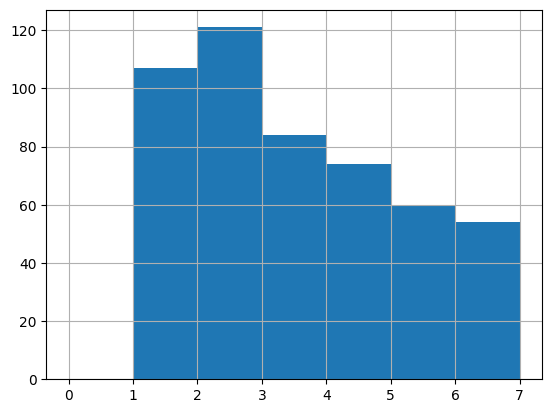

In [2]:
cfg = GPConfig()
grow_only = [random_tree(cfg.max_depth, cfg.min_depth) for _ in range(500)]
ramped = ramped_half_and_half(500, cfg.min_depth, cfg.max_depth)


def describe(pop, name):
    d = pd.Series([t.depth() for t in pop])
    s = pd.Series([t.size() for t in pop])
    print(
        f"{name:10s} | 深度 {d.min()}~{d.max()} (均值{d.mean():.1f}) "
        f"| 节点数 {s.min()}~{s.max()} (均值{s.mean():.1f})"
    )


describe(grow_only, "grow-only")
describe(ramped, "ramped")

# 想看分布形状就画直方图：
pd.Series([t.depth() for t in ramped]).hist(bins=range(0, cfg.max_depth + 2))

## parsimony 惩罚限制


In [3]:
# 复用之前的迷你合成数据（20 只 × 60 天）
dates = pd.date_range("2024-01-01", periods=60, freq="B")
codes = [f"s{i:02d}" for i in range(20)]
idx = pd.MultiIndex.from_product([dates, codes], names=["date", "code"])
rng = np.random.default_rng(0)
prices = pd.DataFrame(
    {
        c: rng.random(len(idx)) * 100 + 10
        for c in ["open", "high", "low", "close", "volume", "amount"]
    },
    index=idx,
)
wide = to_wide(prices)
fwd = compute_forward_returns(wide["close"], period=5)

cfg = GPConfig(population_size=40, generations=8, max_depth=6, min_depth=2)

for alpha in [0.0, 0.005]:
    fn = make_fitness(wide, fwd, parsimony=alpha)
    best_tree, best_score = run_gp(fn, cfg)[0]
    print(f"α={alpha}: 最佳 size={best_tree.size():2d}  score={best_score:.4f}")


Gen   0 | best=4.3691 | mean=0.3784 | expr=neg(neg(close))
Gen   1 | best=4.3691 | mean=1.4576 | expr=neg(neg(close))
Gen   2 | best=4.3691 | mean=3.3522 | expr=neg(neg(close))
Gen   3 | best=4.3691 | mean=4.2114 | expr=neg(neg(close))
Gen   4 | best=4.3691 | mean=3.9361 | expr=neg(neg(close))
Gen   5 | best=4.3691 | mean=4.1581 | expr=neg(neg(close))
Gen   6 | best=4.3691 | mean=4.3691 | expr=neg(neg(close))
Gen   7 | best=4.3691 | mean=4.1538 | expr=neg(neg(close))
α=0.0: 最佳 size= 3  score=4.3691
Gen   0 | best=2.5025 | mean=-0.1524 | expr=mul(close, volume)
Gen   1 | best=4.3641 | mean=1.1499 | expr=close
Gen   2 | best=4.3641 | mean=1.9962 | expr=close
Gen   3 | best=4.3716 | mean=3.1129 | expr=sub(rank(rank(mul(close, volume))), close)
Gen   4 | best=4.3716 | mean=4.1830 | expr=sub(rank(rank(mul(close, volume))), close)
Gen   5 | best=4.3716 | mean=3.8262 | expr=sub(rank(rank(mul(close, volume))), close)
Gen   6 | best=4.3716 | mean=3.3028 | expr=sub(rank(rank(mul(close, volume)))

很不幸地，这里的实验和我们的预期恰好相反，更大的约束反而size更大。

这就意味着，大树的原始 ICIR 更高，惩罚根本没有效果。而且我们 alpha 的尺度在 ICIR 面前未必够用。

另外，这里手贱没有加随机种子，两次实验其实并不能直接对比...下面重新跑。


In [4]:
import random

cfg = GPConfig(population_size=40, generations=8, max_depth=6, min_depth=2)

for alpha in [0.0, 0.05, 0.2]:
    random.seed(0)
    np.random.seed(0)  # 同种子 → 唯一变量就是 α，隔离 parsimony
    fn = make_fitness(wide, fwd, parsimony=alpha)
    best_tree, best_score = run_gp(fn, cfg)[0]
    raw = best_score + alpha * best_tree.size()  # 还原未罚的 |ICIR|，公平比因子质量
    print(f"α={alpha:<5} size={best_tree.size():2d}  raw|ICIR|={raw:.3f}  {best_tree}")

Gen   0 | best=4.3691 | mean=-0.0387 | expr=neg(close)
Gen   1 | best=4.3691 | mean=1.2261 | expr=neg(close)
Gen   2 | best=4.3691 | mean=2.4305 | expr=neg(close)
Gen   3 | best=4.3691 | mean=3.9588 | expr=neg(close)
Gen   4 | best=4.3691 | mean=4.2603 | expr=neg(close)
Gen   5 | best=4.3691 | mean=4.3691 | expr=neg(close)
Gen   6 | best=4.3691 | mean=4.1553 | expr=neg(close)
Gen   7 | best=4.3691 | mean=4.2605 | expr=neg(close)
α=0.0   size= 2  raw|ICIR|=4.369  neg(close)
Gen   0 | best=4.2691 | mean=-0.2550 | expr=neg(close)
Gen   1 | best=4.3191 | mean=0.9585 | expr=close
Gen   2 | best=4.3191 | mean=2.4509 | expr=close
Gen   3 | best=4.3191 | mean=3.8702 | expr=close
Gen   4 | best=4.3191 | mean=4.2090 | expr=close
Gen   5 | best=4.3191 | mean=3.9702 | expr=close
Gen   6 | best=4.3191 | mean=4.1041 | expr=close
Gen   7 | best=4.3191 | mean=4.2105 | expr=close
α=0.05  size= 1  raw|ICIR|=4.369  close
Gen   0 | best=3.9691 | mean=-0.9037 | expr=neg(close)
Gen   1 | best=4.1691 | mean=

可以看到，节点数量是有效被限制了的，而且并没有丢失预测能力。


### NSGA-II 多目标


### Pareto 前沿


57 个有效因子，分成 14 层
第 0 层 = Pareto 前沿（各复杂度下最优的因子）：
  |ICIR|=0.232  size=2   delta(volume)
  |ICIR|=4.369  size=3   log(log(close))


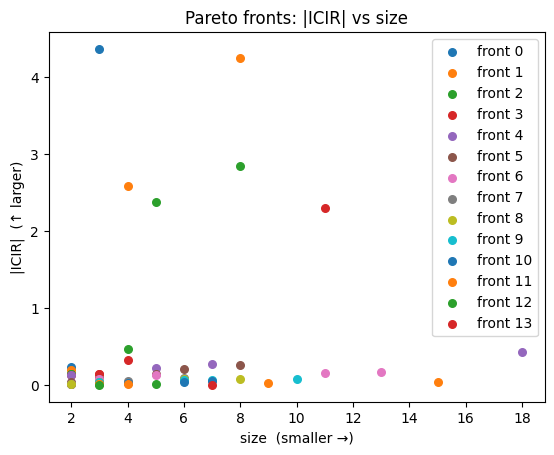

In [5]:
def objectives(tree):
    try:
        ic = calc_ic_series(evaluate(tree, wide), fwd).dropna()
    except Exception:
        return None
    if len(ic) < 10 or not np.isfinite(calc_icir(ic)):
        return None
    return (abs(calc_icir(ic)), tree.size())  # (|ICIR|, size)


pop = ramped_half_and_half(80, 2, 5)
data = [(t, objectives(t)) for t in pop]
data = [(t, o) for t, o in data if o is not None]  # 去掉算崩的
trees = [t for t, _ in data]
objs = [(o[0], -o[1]) for _, o in data]  # 转成都要最大化：(icir, -size)

fronts = non_dominated_sort(objs)
print(f"{len(objs)} 个有效因子，分成 {len(fronts)} 层")
print("第 0 层 = Pareto 前沿（各复杂度下最优的因子）：")
for i in sorted(fronts[0], key=lambda i: -objs[i][1]):  # 按 size 排
    print(f"  |ICIR|={objs[i][0]:.3f}  size={-objs[i][1]:<2d}  {trees[i]}")

# 散点：每层一种颜色，左上角(高ICIR+小size)就是前沿
for rank, fr in enumerate(fronts):
    plt.scatter([-objs[i][1] for i in fr], [objs[i][0] for i in fr], label=f"front {rank}", s=30)
plt.xlabel("size  (smaller →)")
plt.ylabel("|ICIR|  (↑ larger)")
plt.legend()
plt.title("Pareto fronts: |ICIR| vs size")
plt.show()

这里数据点有点少，我们用更多的数据点来画图


60 个点，分成 14 层


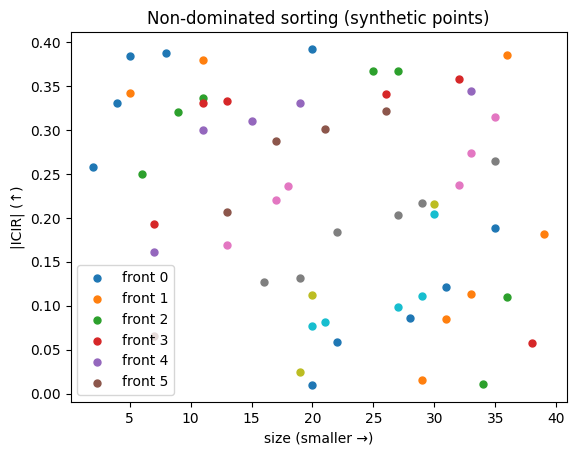

In [6]:
rng = np.random.default_rng(1)
pts = [(rng.uniform(0, 0.4), int(rng.integers(2, 40))) for _ in range(60)]  # 60 个假因子
objs = [(icir, -size) for icir, size in pts]  # 转成都要最大化

fronts = non_dominated_sort(objs)
print(f"{len(objs)} 个点，分成 {len(fronts)} 层")
for rank, fr in enumerate(fronts):
    plt.scatter(
        [-objs[i][1] for i in fr],
        [objs[i][0] for i in fr],
        label=f"front {rank}" if rank < 6 else None,
        s=25,
    )
plt.xlabel("size (smaller →)")
plt.ylabel("|ICIR| (↑)")
plt.legend()
plt.title("Non-dominated sorting (synthetic points)")
plt.show()


### NSGA-II 完整流水线


In [7]:
def objective_fn(tree):
    try:
        ic = calc_ic_series(evaluate(tree, wide), fwd).dropna()
    except Exception:
        return None
    if len(ic) < 10:
        return None
    icir = calc_icir(ic)
    return abs(icir) if np.isfinite(icir) else None


pareto = run_gp_nsga2(
    objective_fn, GPConfig(population_size=40, generations=10, max_depth=5, min_depth=2)
)
print("\n最终 Pareto 前沿（按 size 排）：")
for tree, icir, size in pareto:
    print(f"  |ICIR|={icir:.3f}  size={size:2d}  {tree}")

Gen   0 | front0= 1 | best|ICIR|=4.3691 | sizes=[1.0]

最终 Pareto 前沿（按 size 排）：
  |ICIR|=4.369  size= 1  close
